In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 8.36 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix


In [7]:
# Install PyTorch (Colab usually has it pre-installed, but this ensures compatibility)
!pip install torch torchvision

# Install other dependencies
!pip install dominate
!pip install visdom
!pip install numpy
!pip install matplotlib
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=c781597936ffd64d99d87aae6619bb523a847daa201e35737af7ac9b406adcd1
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [14]:
from google.colab import drive
drive.mount('/content/drive')

# List all files in your main Drive directory
print("Contents of your Google Drive root:")
!ls -la "/content/drive/MyDrive/"

# Also check if it might be in a subfolder
print("\nChecking for zip files anywhere in Drive:")
!find "/content/drive/MyDrive/" -name "*.zip" 2>/dev/null

Mounted at /content/drive
Contents of your Google Drive root:
total 151991
-rw------- 1 root root 13301547 Mar 29 17:12  1d8999f3-c6bb-42f6-ad53-9e168c52ecf7.tmp
-rw------- 1 root root      177 Jun  9 01:15 '2026 Summer Course Schedule.gdoc'
-rw------- 1 root root      177 Apr 19 07:14 '3, Filter ckts.gdoc'
-rw------- 1 root root      177 Jul 17  2025 '4 YEAR TASK PLAN.gslides'
drwx------ 2 root root     4096 Dec 17 17:40  ACHIEVEMENTS
-rw------- 1 root root    59797 Mar 29 21:05 'Aditi_CV__Copy_1 (1).pdf'
-rw------- 1 root root    59646 Mar 29 20:46  Aditi_CV__Copy_1.pdf
-rw------- 1 root root  8007783 Oct 13  2025 'ADITI SHARMA EE.pdf'
-rw------- 1 root root  8989314 Sep 29  2025 'ADITI SHARMA_GRAPHIC DESIGN.pdf'
-rw------- 1 root root  1206367 Sep 29  2025 'ADITI SHARMA_GRAPHIC DESIGN.png'
-rw------- 1 root root 12201379 May 12 16:25 'ADITI S PORTFOLIO.pdf'
-rw------- 1 root root  1225272 Jun  7 19:17 'ADITI-S PORTFOLIO.pdf'
-rw------- 1 root root    47888 May 17 14:28 'AZ Graphic I

In [15]:
import os

# Unzip your dataset
!unzip -q "/content/drive/MyDrive/my_style_transfer.zip" -d "/content/drive/MyDrive/"

# Verify the unzipped location
dataset_path = "/content/drive/MyDrive/my_style_transfer"
print("Dataset contents:")
!ls -la "$dataset_path"

Dataset contents:
total 16
dr-x------ 2 root root 4096 Jun 12 18:47 testA
dr-x------ 2 root root 4096 Jun 12 18:47 testB
dr-x------ 2 root root 4096 Jun 12 17:33 trainA
dr-x------ 2 root root 4096 Jun 12 18:29 trainB


In [16]:
dataset_path = "/content/drive/MyDrive/my_style_transfer"

for folder in ['trainA', 'trainB', 'testA', 'testB']:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.exists(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        print(f"✅ {folder}: {count} images")
    else:
        print(f"❌ {folder}: Not found")

✅ trainA: 200 images
✅ trainB: 100 images
✅ testA: 10 images
✅ testB: 10 images


In [19]:
!python train.py \
    --dataroot /content/drive/MyDrive/my_style_transfer \
    --name art_style_transfer \
    --model cycle_gan \
    --batch_size 1 \
    --n_epochs 50 \
    --n_epochs_decay 50 \
    --preprocess resize_and_crop \
    --crop_size 256 \
    --load_size 286 \
    --save_epoch_freq 10

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/my_style_transfer	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
    

In [20]:
# Test the model on test images
!python test.py \
    --dataroot /content/drive/MyDrive/my_style_transfer \
    --name art_style_transfer \
    --model cycle_gan \
    --epoch latest \
    --num_test 20

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/my_style_transfer	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256   

In [22]:
from IPython.display import Image, display
import os

results_dir = '/content/pytorch-CycleGAN-and-pix2pix/results/art_style_transfer/latest_test/images'

if os.path.exists(results_dir):
    # Show a few sample results
    for f in sorted(os.listdir(results_dir))[:10]:
        if 'fake' in f and f.endswith('.png'):
            print(f"\n{f}:")
            display(Image(filename=os.path.join(results_dir, f)))

In [23]:
import shutil

# Copy the trained generator to Google Drive
src = '/content/pytorch-CycleGAN-and-pix2pix/checkpoints/art_style_transfer/latest_net_G_A.pth'
dst = '/content/drive/MyDrive/art_style_transfer_generator.pth'

shutil.copy(src, dst)
print(f"✅ Model saved to: {dst}")

✅ Model saved to: /content/drive/MyDrive/art_style_transfer_generator.pth


In [25]:
import os
if os.path.exists('/content/pytorch-CycleGAN-and-pix2pix'):
    os.chdir('/content/pytorch-CycleGAN-and-pix2pix')
    print("✅ In CycleGAN directory:", os.getcwd())
else:
    print("❌ CycleGAN directory not found. Clone it first:")
    !git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
    os.chdir('/content/pytorch-CycleGAN-and-pix2pix')

✅ In CycleGAN directory: /content/pytorch-CycleGAN-and-pix2pix


In [41]:
import torch
from models import create_model
from data import create_dataset
from util import util
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the trained model
opt = type('Options', (), {})()
opt.dataroot = '/content/drive/MyDrive/my_style_transfer'
opt.name = 'art_style_transfer'
opt.model = 'cycle_gan'
opt.phase = 'test'
opt.num_threads = 0
opt.batch_size = 1
opt.serial_batches = True
opt.no_flip = True
opt.load_iter = 0
opt.epoch = 'latest'
opt.verbose = False
opt.gpu_ids = [0]
opt.isTrain = False # Set isTrain to False for inference
opt.checkpoints_dir = './checkpoints' # Add checkpoints_dir
opt.device = torch.device('cuda:{}'.format(opt.gpu_ids[0])) if opt.gpu_ids else torch.device('cpu') # Set the device
opt.preprocess = 'resize_and_crop' # Add preprocess option
opt.input_nc = 3 # Add input_nc (number of input channels, typically 3 for RGB)
opt.output_nc = 3 # Add output_nc (number of output channels, typically 3 for RGB)
opt.ngf = 64 # Number of generator filters in the last conv layer
opt.netG = 'resnet_9blocks' # Generator network architecture
opt.norm = 'instance' # Normalization layer type
opt.no_dropout = True # No dropout for the generator
opt.init_type = 'normal' # Initializer for network weights
opt.init_gain = 0.02 # Initializer gain for normal, xavier and orthogonal

# Create model
model = create_model(opt)
model.setup(opt)
model.eval()

print("✅ Model loaded successfully!")

model [CycleGANModel] was created
Initialized with device cuda:0
initialize network with normal
loading the model from checkpoints/art_style_transfer/latest_net_G_A.pth
Initialized with device cuda:0
initialize network with normal
loading the model from checkpoints/art_style_transfer/latest_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 11.378 M
[Network G_B] Total number of parameters : 11.378 M
-----------------------------------------------
✅ Model loaded successfully!


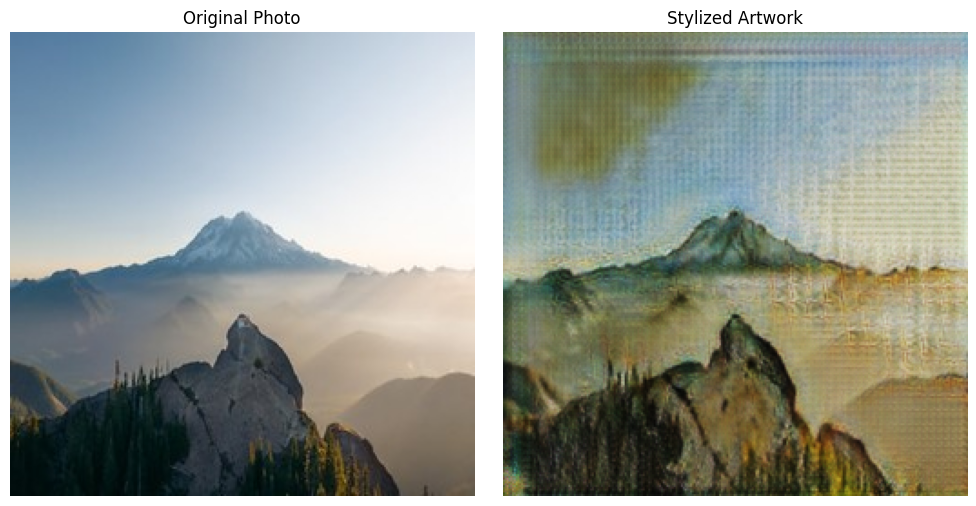

✅ Stylized image saved to: /content/stylized_output.jpg


In [44]:
# Load a specific test image
import os
from PIL import Image
import numpy as np
import torch

# Path to your test image (change the filename to any image in your testA folder)
test_image_path = '/content/drive/MyDrive/my_style_transfer/testA/photo_0016.jpg'

# Load and preprocess the image
def load_image(image_path, target_size=(256, 256)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.LANCZOS)

    # Convert to tensor (normalize to [-1, 1])
    img_array = np.array(img).astype(np.float32)
    img_array = (img_array - 127.5) / 127.5
    img_tensor = torch.from_numpy(img_array.transpose(2, 0, 1)).unsqueeze(0)

    return img_tensor

# Load your test image
input_image = load_image(test_image_path)

# Move to GPU if available
if torch.cuda.is_available():
    input_image = input_image.cuda()

# Generate stylized image
with torch.no_grad():
    stylized_image = model.netG_A(input_image) # Corrected from model.net_G_A

# Convert back to displayable format
def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.squeeze(0)
    tensor = (tensor + 1) / 2  # Denormalize from [-1,1] to [0,1]
    tensor = tensor.clamp(0, 1)
    img = tensor.permute(1, 2, 0).numpy()
    return img

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
original_img = tensor_to_image(input_image)
axes[0].imshow(original_img)
axes[0].set_title('Original Photo')
axes[0].axis('off')

# Stylized image
stylized_img = tensor_to_image(stylized_image)
axes[1].imshow(stylized_img)
axes[1].set_title('Stylized Artwork')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the stylized image
output_path = '/content/stylized_output.jpg'
stylized_img_save = (stylized_img * 255).astype(np.uint8)
Image.fromarray(stylized_img_save).save(output_path)
print(f"✅ Stylized image saved to: {output_path}")

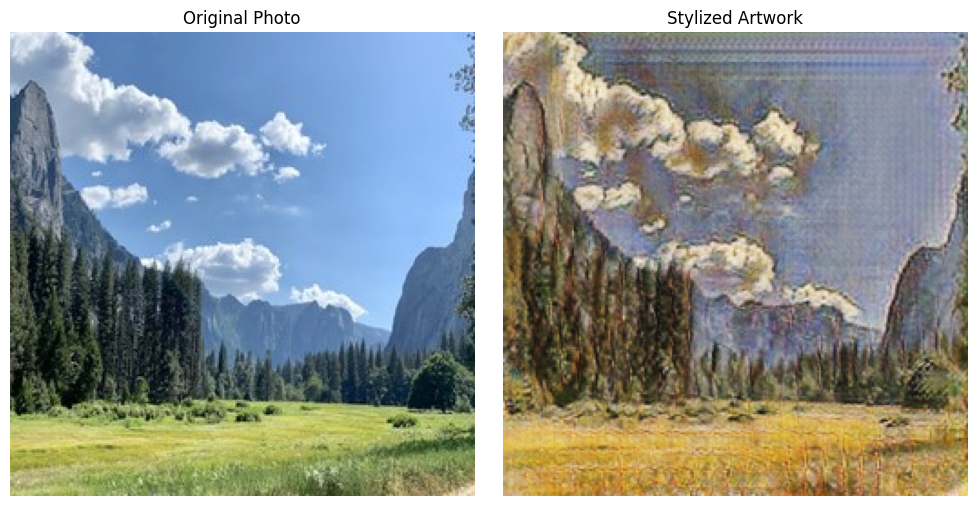

✅ Stylized image saved to: /content/stylized_output.jpg


In [45]:
# Load a specific test image
import os
from PIL import Image
import numpy as np
import torch

# Path to your test image (change the filename to any image in your testA folder)
test_image_path = '/content/drive/MyDrive/my_style_transfer/testA/photo_0045.jpg'

# Load and preprocess the image
def load_image(image_path, target_size=(256, 256)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.LANCZOS)

    # Convert to tensor (normalize to [-1, 1])
    img_array = np.array(img).astype(np.float32)
    img_array = (img_array - 127.5) / 127.5
    img_tensor = torch.from_numpy(img_array.transpose(2, 0, 1)).unsqueeze(0)

    return img_tensor

# Load your test image
input_image = load_image(test_image_path)

# Move to GPU if available
if torch.cuda.is_available():
    input_image = input_image.cuda()

# Generate stylized image
with torch.no_grad():
    stylized_image = model.netG_A(input_image) # Corrected from model.net_G_A

# Convert back to displayable format
def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.squeeze(0)
    tensor = (tensor + 1) / 2  # Denormalize from [-1,1] to [0,1]
    tensor = tensor.clamp(0, 1)
    img = tensor.permute(1, 2, 0).numpy()
    return img

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
original_img = tensor_to_image(input_image)
axes[0].imshow(original_img)
axes[0].set_title('Original Photo')
axes[0].axis('off')

# Stylized image
stylized_img = tensor_to_image(stylized_image)
axes[1].imshow(stylized_img)
axes[1].set_title('Stylized Artwork')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the stylized image
output_path = '/content/stylized_output.jpg'
stylized_img_save = (stylized_img * 255).astype(np.uint8)
Image.fromarray(stylized_img_save).save(output_path)
print(f"✅ Stylized image saved to: {output_path}")

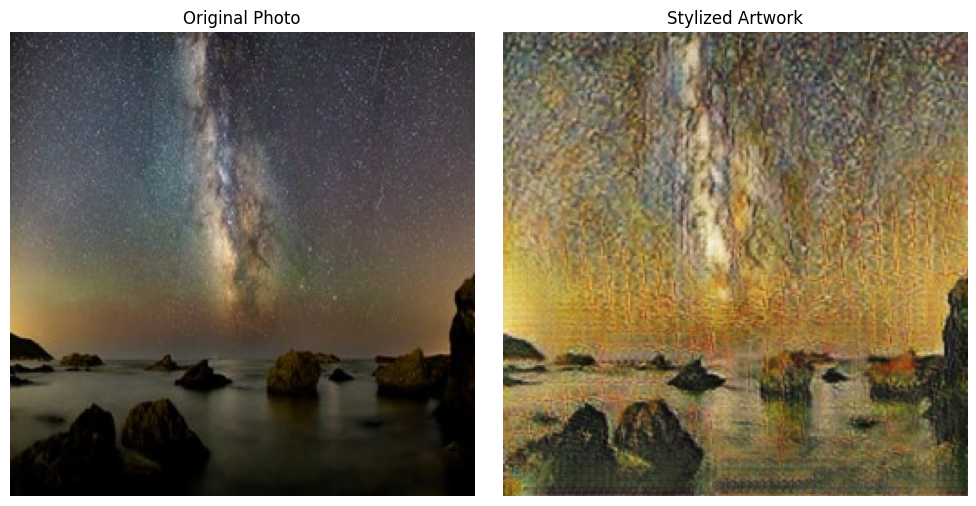

✅ Stylized image saved to: /content/stylized_output.jpg


In [47]:
# Load a specific test image
import os
from PIL import Image
import numpy as np
import torch

# Path to your test image (change the filename to any image in your testA folder)
test_image_path = '/content/drive/MyDrive/my_style_transfer/testA/photo_0022.jpg'

# Load and preprocess the image
def load_image(image_path, target_size=(256, 256)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.LANCZOS)

    # Convert to tensor (normalize to [-1, 1])
    img_array = np.array(img).astype(np.float32)
    img_array = (img_array - 127.5) / 127.5
    img_tensor = torch.from_numpy(img_array.transpose(2, 0, 1)).unsqueeze(0)

    return img_tensor

# Load your test image
input_image = load_image(test_image_path)

# Move to GPU if available
if torch.cuda.is_available():
    input_image = input_image.cuda()

# Generate stylized image
with torch.no_grad():
    stylized_image = model.netG_A(input_image) # Corrected from model.net_G_A

# Convert back to displayable format
def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.squeeze(0)
    tensor = (tensor + 1) / 2  # Denormalize from [-1,1] to [0,1]
    tensor = tensor.clamp(0, 1)
    img = tensor.permute(1, 2, 0).numpy()
    return img

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
original_img = tensor_to_image(input_image)
axes[0].imshow(original_img)
axes[0].set_title('Original Photo')
axes[0].axis('off')

# Stylized image
stylized_img = tensor_to_image(stylized_image)
axes[1].imshow(stylized_img)
axes[1].set_title('Stylized Artwork')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the stylized image
output_path = '/content/stylized_output.jpg'
stylized_img_save = (stylized_img * 255).astype(np.uint8)
Image.fromarray(stylized_img_save).save(output_path)
print(f"✅ Stylized image saved to: {output_path}")

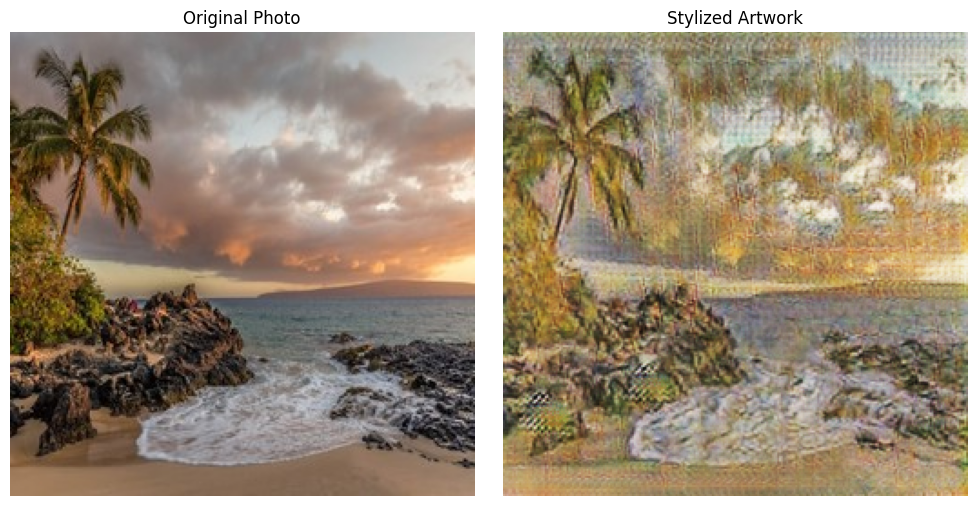

✅ Stylized image saved to: /content/stylized_output.jpg


In [48]:
# Load a specific test image
import os
from PIL import Image
import numpy as np
import torch

# Path to your test image (change the filename to any image in your testA folder)
test_image_path = '/content/drive/MyDrive/my_style_transfer/testA/photo_0197.jpg'

# Load and preprocess the image
def load_image(image_path, target_size=(256, 256)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size, Image.LANCZOS)

    # Convert to tensor (normalize to [-1, 1])
    img_array = np.array(img).astype(np.float32)
    img_array = (img_array - 127.5) / 127.5
    img_tensor = torch.from_numpy(img_array.transpose(2, 0, 1)).unsqueeze(0)

    return img_tensor

# Load your test image
input_image = load_image(test_image_path)

# Move to GPU if available
if torch.cuda.is_available():
    input_image = input_image.cuda()

# Generate stylized image
with torch.no_grad():
    stylized_image = model.netG_A(input_image) # Corrected from model.net_G_A

# Convert back to displayable format
def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.squeeze(0)
    tensor = (tensor + 1) / 2  # Denormalize from [-1,1] to [0,1]
    tensor = tensor.clamp(0, 1)
    img = tensor.permute(1, 2, 0).numpy()
    return img

# Display results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
original_img = tensor_to_image(input_image)
axes[0].imshow(original_img)
axes[0].set_title('Original Photo')
axes[0].axis('off')

# Stylized image
stylized_img = tensor_to_image(stylized_image)
axes[1].imshow(stylized_img)
axes[1].set_title('Stylized Artwork')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the stylized image
output_path = '/content/stylized_output.jpg'
stylized_img_save = (stylized_img * 255).astype(np.uint8)
Image.fromarray(stylized_img_save).save(output_path)
print(f"✅ Stylized image saved to: {output_path}")

In [52]:
!pip install pytorch-fid pytorch-msssim lpips tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.6 MB/s eta 0:00:00


In [53]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import sys
sys.path.append('/content/pytorch-CycleGAN-and-pix2pix')

from pytorch_fid import fid_score
from pytorch_msssim import ssim
import lpips
import torch.nn.functional as F
from torchvision import transforms
from data.base_dataset import get_transform

print("✅ Libraries imported")
print(f"GPU: {torch.cuda.is_available()}")

✅ Libraries imported
GPU: True


In [57]:
# Paths (update if different)
testA_path = '/content/drive/MyDrive/my_style_transfer/testA'
testB_path = '/content/drive/MyDrive/my_style_transfer/testB'
output_dir = '/content/evaluation_images'

os.makedirs(output_dir, exist_ok=True)

# Get test images
test_images = [f for f in os.listdir(testA_path) if f.endswith('.jpg')]
print(f"📸 Found {len(test_images)} test images")

# Add load_size and crop_size to opt object, required by get_transform
opt.load_size = 256
opt.crop_size = 256

# Get transformation
transform = get_transform(opt, grayscale=False, convert=True)

# Generate images
print("\n🎨 Generating stylized images...")
for img_name in tqdm(test_images, desc="Processing"):
    img_path = os.path.join(testA_path, img_name)
    img = Image.open(img_path).convert('RGB')

    tensor_image = transform(img).unsqueeze(0)
    if torch.cuda.is_available():
        tensor_image = tensor_image.cuda()

    with torch.no_grad():
        generated = model.netG_A(tensor_image)

    generated = generated.detach().cpu()
    img_numpy = (generated.squeeze().numpy().transpose(1, 2, 0) + 1) / 2
    img_numpy = np.clip(img_numpy, 0, 1)
    img_numpy = (img_numpy * 255).astype(np.uint8)

    output_path = os.path.join(output_dir, img_name)
    Image.fromarray(img_numpy).save(output_path)

print(f"✅ Generated {len(test_images)} images")

📸 Found 10 test images

🎨 Generating stylized images...


Processing: 100%|██████████| 10/10 [00:00<00:00, 24.90it/s]

✅ Generated 10 images


In [58]:
print("="*50)
print("📊 CALCULATING FID SCORE")
print("="*50)

fid_value = fid_score.calculate_fid_given_paths(
    paths=[testB_path, output_dir],
    batch_size=16,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    dims=2048,
    num_workers=2
)

print(f"\n🎯 FID Score: {fid_value:.2f}")

📊 CALCULATING FID SCORE
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:03<00:00, 30.1MB/s]


100%|██████████| 1/1 [00:01<00:00,  1.03s/it]


100%|██████████| 1/1 [00:00<00:00,  6.68it/s]



🎯 FID Score: 397.47


In [59]:
print("\n" + "="*50)
print("📊 CALCULATING SSIM, PSNR, LPIPS")
print("="*50)

transform_metric = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Initialize LPIPS
lpips_fn = lpips.LPIPS(net='alex')
if torch.cuda.is_available():
    lpips_fn = lpips_fn.cuda()

ssim_scores = []
psnr_scores = []
lpips_scores = []

for img_name in tqdm(test_images, desc="Computing metrics"):
    input_img = Image.open(os.path.join(testA_path, img_name)).convert('RGB')
    gen_img = Image.open(os.path.join(output_dir, img_name)).convert('RGB')

    input_tensor = transform_metric(input_img).unsqueeze(0)
    gen_tensor = transform_metric(gen_img).unsqueeze(0)

    if torch.cuda.is_available():
        input_tensor = input_tensor.cuda()
        gen_tensor = gen_tensor.cuda()

    # SSIM
    ssim_val = ssim(input_tensor, gen_tensor, data_range=1.0)
    ssim_scores.append(ssim_val.item())

    # PSNR
    mse = F.mse_loss(input_tensor, gen_tensor)
    psnr_val = 20 * torch.log10(1.0 / torch.sqrt(mse))
    psnr_scores.append(psnr_val.item())

    # LPIPS
    lpips_val = lpips_fn(input_tensor, gen_tensor)
    lpips_scores.append(lpips_val.item())

print(f"\n🖼️ SSIM: {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f}")
print(f"📡 PSNR: {np.mean(psnr_scores):.2f} ± {np.std(psnr_scores):.2f} dB")
print(f"👁️ LPIPS: {np.mean(lpips_scores):.4f} ± {np.std(lpips_scores):.4f}")


📊 CALCULATING SSIM, PSNR, LPIPS
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 99.2MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Computing metrics: 100%|██████████| 10/10 [00:00<00:00, 18.60it/s]


🖼️ SSIM: 0.5123 ± 0.0574
📡 PSNR: 15.50 ± 2.04 dB
👁️ LPIPS: 0.3844 ± 0.0693


In [66]:
results = {
    'FID': round(fid_value, 2),
    'SSIM': round(np.mean(ssim_scores), 4),
    'PSNR': round(np.mean(psnr_scores), 2),
    'LPIPS': round(np.mean(lpips_scores), 4),
    'num_images': len(test_images)
}

print("\n" + "="*50)
print("📊 FINAL EVALUATION SUMMARY")
print("="*50)
print(f"""
┌─────────────────────────────────────────────────────────────┐
│                   CYCLEGAN MODEL SCORES                     │
├─────────────────────────────────────────────────────────────┤
│  🎯 FID:     {results['FID']}
│  🖼️ SSIM:    {results['SSIM']}
│  📡 PSNR:    {results['PSNR']} dB
│  👁️ LPIPS:   {results['LPIPS']}
├─────────────────────────────────────────────────────────────┤
│  📸 Test images: {results['num_images']}
└─────────────────────────────────────────────────────────────┘

📌 Quick Interpretation:
""")

if results['FID'] < 100:
    print("   ✅ FID: Excellent - Images look very realistic")
elif results['FID'] < 180:
    print("   👍 FID: Good - Style transfer is working well")
else:
    print("   ⚠️ FID: Needs improvement - Consider more training")

if results['SSIM'] > 0.4:
    print("   ✅ SSIM: Good structure preservation")
else:
    print("   ⚠️ SSIM: Significant structural changes")

if results['PSNR'] > 25:
    print("   ✅ PSNR: Good image quality")
else:
    print("   ⚠️ PSNR: Quality could be improved")

print("\n" + "="*50)


📊 FINAL EVALUATION SUMMARY

┌─────────────────────────────────────────────────────────────┐
│                   CYCLEGAN MODEL SCORES                     │
├─────────────────────────────────────────────────────────────┤
│  🎯 FID:     397.47                               
│  🖼️ SSIM:    0.5123                             
│  📡 PSNR:    15.5 dB                           
│  👁️ LPIPS:   0.3844                             
├─────────────────────────────────────────────────────────────┤
│  📸 Test images: 10                   
└─────────────────────────────────────────────────────────────┘

📌 Quick Interpretation:

   ⚠️ FID: Needs improvement - Consider more training
   ✅ SSIM: Good structure preservation
   ⚠️ PSNR: Quality could be improved

